In [6]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

base = Path.cwd().parent

raw = base / "data" / "raw"
processed = base / "data" / "processed"
charts = base / "reports" / "charts"

fund_master = pd.read_csv(raw / "01_fund_master.csv")

nav = pd.read_csv(
    processed / "nav_history_clean.csv",
    parse_dates=["date"]
)

transactions = pd.read_csv(
    processed / "investor_transactions_clean.csv",
    parse_dates=["transaction_date"]
)

scorecard = pd.read_csv(
    processed / "fund_scorecard.csv"
)

holdings = pd.read_csv(
    raw / "09_portfolio_holdings.csv"
)

nav = pd.read_csv(
    processed / "nav_history_clean.csv",
    parse_dates=["date"]
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print(nav.head())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


In [7]:
var_results = []

for code in nav["amfi_code"].unique():

    returns = (
        nav[nav["amfi_code"] == code]
        ["daily_return"]
        .dropna()
    )

    if len(returns) < 30:
        continue

    var_95 = np.percentile(returns, 5)

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    var_results.append([
        code,
        var_95,
        cvar_95
    ])

var_cvar = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "var_95",
        "cvar_95"
    ]
)

var_cvar = var_cvar.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

var_cvar.head()

,amfi_code,var_95,cvar_95,scheme_name
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth


In [8]:
var_cvar.to_csv(
    processed / "var_cvar_report.csv",
    index=False
)

print("Saved var_cvar_report.csv")

Saved var_cvar_report.csv


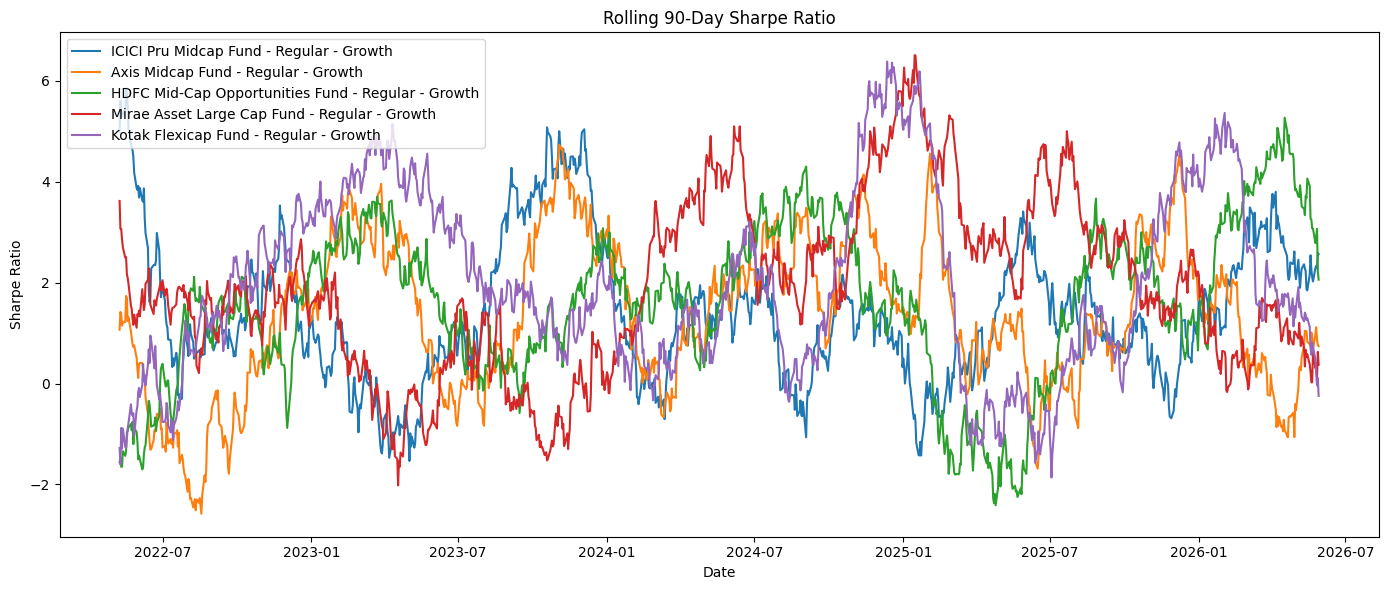

In [9]:
top_funds = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)
    ["amfi_code"]
    .tolist()
)

plt.figure(figsize=(14,6))

for code in top_funds:

    temp = (
        nav[nav["amfi_code"] == code]
        .sort_values("date")
        .copy()
    )

    rolling_sharpe = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    name = (
        fund_master[
            fund_master["amfi_code"] == code
        ]["scheme_name"]
        .iloc[0]
    )

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=name
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.legend()

plt.tight_layout()

plt.savefig(
    charts / "rolling_sharpe_chart.png"
)

plt.show()

In [10]:
first_txn = (
    transactions
    .groupby("investor_id")
    ["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

transactions = transactions.merge(
    first_txn[
        ["investor_id","cohort_year"]
    ],
    on="investor_id"
)

cohort_summary = (
    transactions
    .groupby("cohort_year")
    .agg(
        avg_investment=(
            "amount_inr",
            "mean"
        ),
        total_invested=(
            "amount_inr",
            "sum"
        )
    )
    .reset_index()
)

top_funds = (
    transactions
    .groupby(
        ["cohort_year","amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

top_funds = (
    top_funds
    .sort_values(
        ["cohort_year","count"],
        ascending=[True,False]
    )
    .drop_duplicates(
        "cohort_year"
    )
)

cohort_summary = cohort_summary.merge(
    top_funds[
        ["cohort_year","amfi_code"]
    ],
    on="cohort_year"
)

cohort_summary.head()

,cohort_year,avg_investment,total_invested,amfi_code
0,2024,107422.541832,3491125187,148568
1,2025,109158.577061,30455243,119599


In [11]:
cohort_summary.to_csv(
    processed / "cohort_analysis.csv",
    index=False
)

print("Saved cohort_analysis.csv")

Saved cohort_analysis.csv


In [12]:
sip = transactions[
    transactions["transaction_type"]
    .str.upper()
    == "SIP"
].copy()

sip = sip.sort_values(
    [
        "investor_id",
        "transaction_date"
    ]
)

continuity = []

for investor, group in sip.groupby(
    "investor_id"
):

    if len(group) < 6:
        continue

    gaps = (
        group["transaction_date"]
        .diff()
        .dt.days
        .dropna()
    )

    avg_gap = gaps.mean()

    status = (
        "At Risk"
        if avg_gap > 35
        else "Healthy"
    )

    continuity.append([
        investor,
        avg_gap,
        status
    ])

sip_continuity = pd.DataFrame(
    continuity,
    columns=[
        "investor_id",
        "avg_gap_days",
        "status"
    ]
)

sip_continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [13]:
sip_continuity.to_csv(
    processed / "sip_continuity.csv",
    index=False
)

print("Saved sip_continuity.csv")

Saved sip_continuity.csv


In [14]:
holdings["weight"] = (
    holdings["weight_pct"] / 100
)

hhi = (
    holdings
    .groupby("amfi_code")
    ["weight"]
    .apply(
        lambda x: np.sum(
            np.square(x)
        )
    )
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "hhi"
]

hhi = hhi.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,hhi,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth


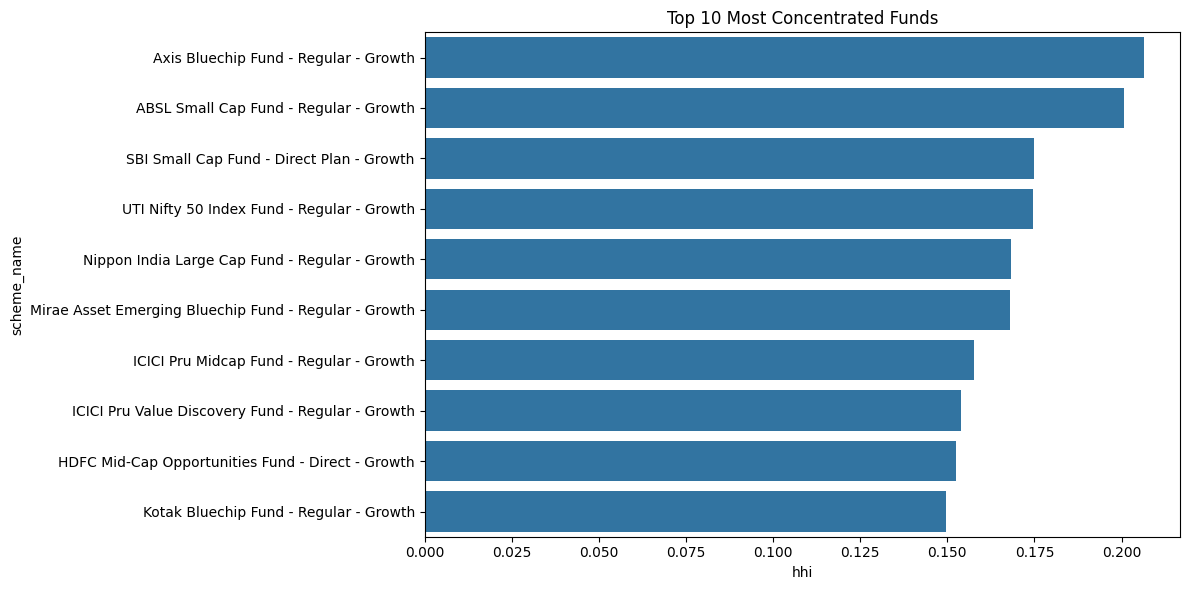

In [15]:
hhi.to_csv(
    processed / "sector_hhi.csv",
    index=False
)

top_hhi = (
    hhi
    .sort_values(
        "hhi",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_hhi,
    x="hhi",
    y="scheme_name"
)

plt.title(
    "Top 10 Most Concentrated Funds"
)

plt.tight_layout()

plt.savefig(
    charts / "sector_hhi_chart.png"
)

plt.show()

In [16]:
recommendation_df = scorecard.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "risk_category"
        ]
    ],
    on="amfi_code"
)

recommendation_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score,scheme_name,risk_category
0,120505,0.296047,0.317775,0.283768,1.180101,0.292636,0.000549,-0.181885,1.36,0.900,0.900,0.950,0.650,0.625,84.50,ICICI Pru Midcap Fund - Regular - Growth,High
1,119094,0.222611,0.351118,0.244453,0.998231,0.260767,-0.066265,-0.209609,1.38,1.000,0.750,0.800,0.600,0.700,80.75,Axis Midcap Fund - Regular - Growth,High
2,100033,0.532324,0.324425,0.260741,1.093699,0.271954,0.005104,-0.162172,1.38,0.925,0.850,0.875,0.600,0.500,80.50,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High
3,148567,0.203607,0.340009,0.267993,1.448291,0.269838,0.023684,-0.112657,1.46,0.975,1.000,0.850,0.450,0.200,80.00,Mirae Asset Large Cap Fund - Regular - Growth,Moderate
4,120843,0.266571,0.295828,0.267425,1.306744,0.273305,-0.022830,-0.129740,1.45,0.850,0.975,0.900,0.475,0.325,78.25,Kotak Flexicap Fund - Regular - Growth,Moderately High


In [17]:
recommendation_df.to_csv(
    processed / "recommendation_data.csv",
    index=False
)

print("recommendation_data.csv")